In [2]:
from google.colab import files
uploaded = files.upload()

Saving paddydataset.csv to paddydataset.csv


In [3]:
# Pandas is used for reading and working with datasets
import pandas as pd

# NumPy is used for mathematical calculations
import numpy as np

# Matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# Splits dataset into Training and Testing data
from sklearn.model_selection import train_test_split

# Linear Regression Algorithm
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df=pd.read_csv("paddydataset.csv")

In [5]:
print("\nFirst Five Rows")
df.head()


First Five Rows


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [6]:
print("\nDataset Information")
df.info()

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days           

In [7]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
Hectares                              0
Agriblock                             0
Variety                               0
Soil Types                            0
Seedrate(in Kg)                       0
LP_Mainfield(in Tonnes)               0
Nursery                               0
Nursery area (Cents)                  0
LP_nurseryarea(in Tonnes)             0
DAP_20days                            0
Weed28D_thiobencarb                   0
Urea_40Days                           0
Potassh_50Days                        0
Micronutrients_70Days                 0
Pest_60Day(in ml)                     0
30DRain( in mm)                       0
30DAI(in mm)                          0
30_50DRain( in mm)                    0
30_50DAI(in mm)                       0
51_70DRain(in mm)                     0
51_70AI(in mm)                        0
71_105DRain(in mm)                    0
71_105DAI(in mm)                      0
Min temp_D1_D30                       0
Max temp_D1_D30         

In [8]:
print(df.duplicated().sum())

451


In [9]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


In [10]:
x = df.drop(['Paddy yield(in Kg)'], axis=1)

In [11]:
y = df['Paddy yield(in Kg)']

In [12]:
categorical_cols = x.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the entire x DataFrame
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

In [13]:
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (2338, 63)
Shape of y: (2338,)


In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (1870, 63)
Shape of y_train: (1870,)
Shape of x_test: (468, 63)
Shape of y_test: (468,)


In [16]:
model = LinearRegression()

model.fit(x_train, y_train)

print("\nModel Training Completed")




Model Training Completed


In [17]:
y_pred = model.predict(x_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())


   Actual     Predicted
0   31555  30445.954973
1   17949  17825.528098
2   30795  30451.215209
3    5836   5446.501718
4   30285  30292.852660


In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("-" * 40)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)



Evaluation Metrics
----------------------------------------
MAE : 768.3663327907934
MSE : 1040176.3606661897
RMSE : 1019.8903669837213
R2 Score : 0.9878498201896799


In [19]:
coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance")
print(coef)



Feature Importance
                        Feature  Coefficient
0                     Hectares      0.020434
1               Seedrate(in Kg)     0.510857
2       LP_Mainfield(in Tonnes)     0.255429
3          Nursery area (Cents)     0.408686
4     LP_nurseryarea(in Tonnes)     0.020434
..                          ...          ...
58   Wind Direction_D91_D120_NW     0.889545
59    Wind Direction_D91_D120_S    -1.221844
60  Wind Direction_D91_D120_SSE     0.465874
61    Wind Direction_D91_D120_W     0.418155
62  Wind Direction_D91_D120_WSW    -2.622906

[63 rows x 2 columns]


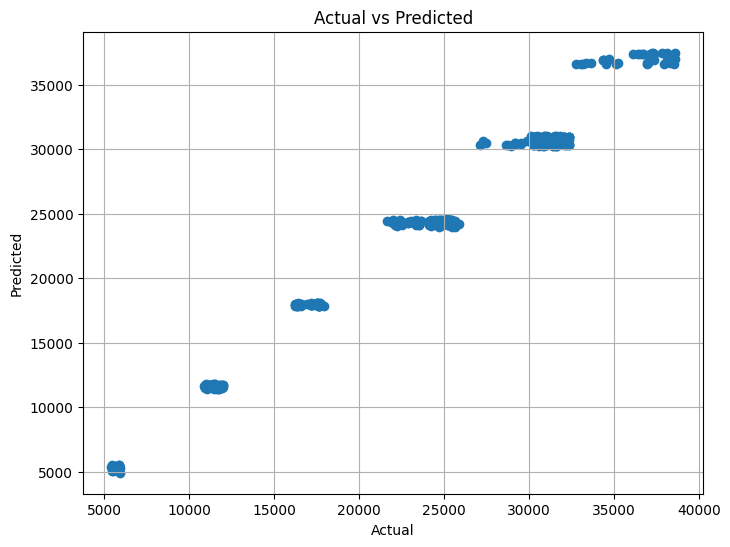

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()


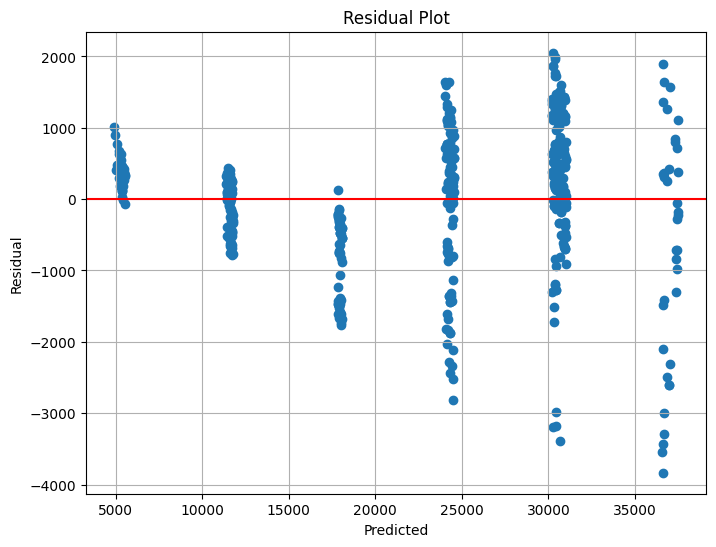

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()
